#### Comparitive Study on Sentiment Analysis of Political Speeches: Analyzing the Prime Minister's and Rahul Gandhi 

In [ ]:
# pip install nltk wordcloud plotly seaborn


This project performs NLP–based sentiment analysis on a political speech delivered by Narendra Modi.

The goal is to understand the emotional tone, sentiment distribution, and key themes present in the speech using industry-standard NLP techniques and visualization tools.

The analysis combines sentence-level sentiment scoring with text preprocessing and word cloud visualization to provide both quantitative and qualitative insights.


🔹 Objectives

    Analyze the sentiment polarity (Positive, Negative, Neutral) of a political speech
    
    Perform sentence-level sentiment analysis using VADER
    
    Identify frequently used words and themes
    
    Visualize sentiment distribution and key terms
    
    Demonstrate real-world NLP workflow used in media and political analysis

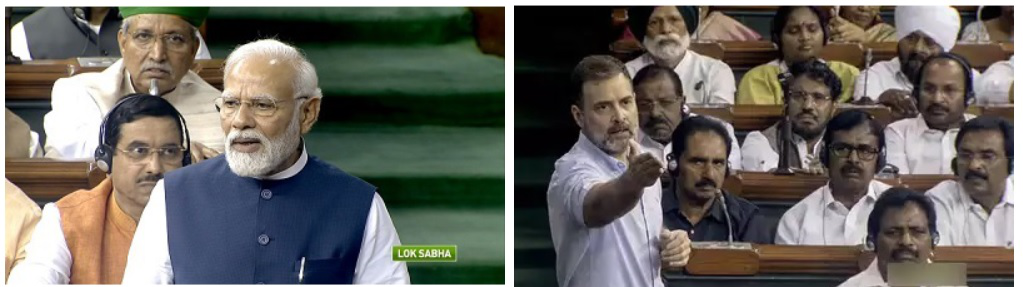

In [1]:
from IPython.display import display
from PIL import Image

image1 = Image.open("Modi Rahul.jpg")
display(image1)

In [58]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
import warnings
warnings.filterwarnings('ignore')

In [60]:
file_path = "Rahul Gandhi Speech.txt"

In [61]:
with open(file_path, "r", encoding="utf-8") as file:
    speech_text = file.read()

In [62]:
print(speech_text)

"Joking In Parliament When Manipur Is On Fire": Rahul Gandhi Slams PM Modi

The Prime Minister "wants Manipur to burn and allows it to burn", Mr Gandhi alleged at a press conference at the AICC headquarters in Delhi and asserted that if the Modi government wanted to stop the violence, there are tools in the hands of the government that can stop it immediately.


"I watched the Prime Minister yesterday, speaking for two hours, laughing, joking, and raising slogans in Parliament. The Prime Minister would say one line and the BJP (leaders) would shout another slogan. The Prime Minister seems to have forgotten that the state of Manipur is on fire and has been on fire for four months,"

"Women and children are dying over there, women are being molested and raped and the Prime Minister of India is sitting in the middle of Parliament and laughing. This is not about Rahul Gandhi, it is not about the Congress, it is not about opposition, it is about India, it is about our country. A state has b

In [63]:
import nltk


In [64]:
#!pip install wordcloud

In [65]:
#nltk.download('stopwords')

In [66]:
#nltk.download('wordnet')

In [67]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [68]:
#nltk.download('vader_lexicon')

In [69]:

speech_text_cleaned = re.sub(r'[^\w\s]', '', speech_text)
                            
speech_text_cleaned = speech_text_cleaned.lower()
                             
words = word_tokenize(speech_text_cleaned)

stop_words = set(stopwords.words("english"))

words_filtered = [word for word in words if word not in stop_words]


In [70]:
words_filtered[:10]

['joking',
 'parliament',
 'manipur',
 'fire',
 'rahul',
 'gandhi',
 'slams',
 'pm',
 'modi',
 'prime']

In [71]:
lemmatizer = WordNetLemmatizer()

words_lemmatized = [lemmatizer.lemmatize(word) for word in words_filtered]

words_lemmatized[:10]

['joking',
 'parliament',
 'manipur',
 'fire',
 'rahul',
 'gandhi',
 'slam',
 'pm',
 'modi',
 'prime']

In [72]:
sia = SentimentIntensityAnalyzer()

sentiment_scores = [sia.polarity_scores(word)["compound"] for word in words_lemmatized]

#average_sentiment = sum(sentiment_scores) / len(sentiment_scores)

In [73]:
sentiment_scores[:10]

[0.2263, 0.0, 0.0, -0.34, 0.0, 0.0, -0.3818, 0.0, 0.0, 0.0]

In [74]:
#print('The average sentiment is:', average_sentiment)

In [75]:
positive_words = [word for i, word in enumerate(words_filtered) if sentiment_scores[i] > 0.1]
negative_words = [word for i, word in enumerate(words_filtered) if sentiment_scores[i] < -0.1]
neutral_words = [word for i, word in enumerate(words_filtered) if sentiment_scores[i] >= -0.1 and sentiment_scores[i] <= 0.1]

In [76]:
print('The positive words are:', positive_words[:10])

The positive words are: ['joking', 'hands', 'laughing', 'joking', 'laughing', 'peacefully', 'harmoniously', 'affection', 'hands', 'faith']


In [77]:
print('The negative words are:', negative_words[:10])

The negative words are: ['fire', 'slams', 'stop', 'violence', 'stop', 'forgotten', 'fire', 'fire', 'molested', 'raped']


In [78]:
print('The neutral words are:', neutral_words[:10])

The neutral words are: ['parliament', 'manipur', 'rahul', 'gandhi', 'pm', 'modi', 'prime', 'minister', 'wants', 'manipur']


In [79]:
word_freq_positive = nltk.FreqDist(positive_words)
word_freq_negative = nltk.FreqDist(negative_words)
word_freq_neutral = nltk.FreqDist(neutral_words)

In [80]:
print('The positive words frequency is:', word_freq_positive)

The positive words frequency is: <FreqDist with 9 samples and 12 outcomes>


In [81]:
print('The negative words frequency is:', word_freq_negative)

The negative words frequency is: <FreqDist with 17 samples and 28 outcomes>


In [82]:
print('The neutral words frequency is:', word_freq_neutral)

The neutral words frequency is: <FreqDist with 125 samples and 241 outcomes>


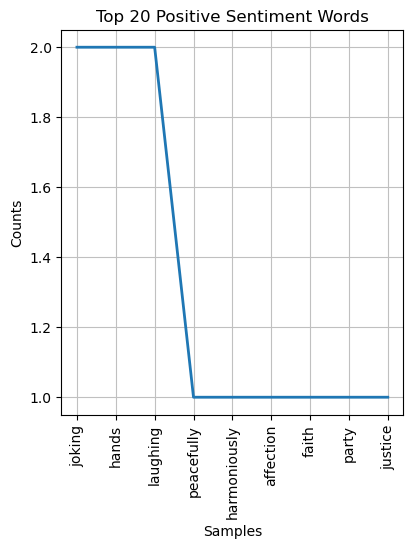

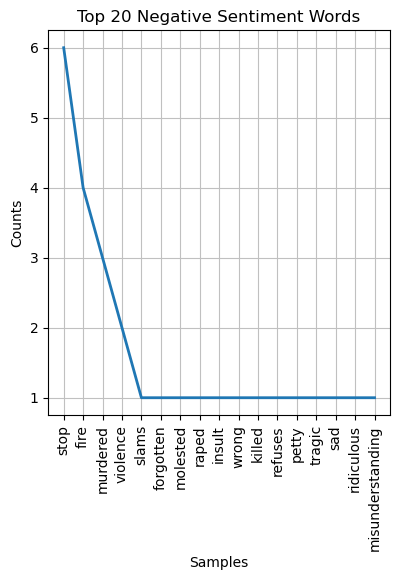

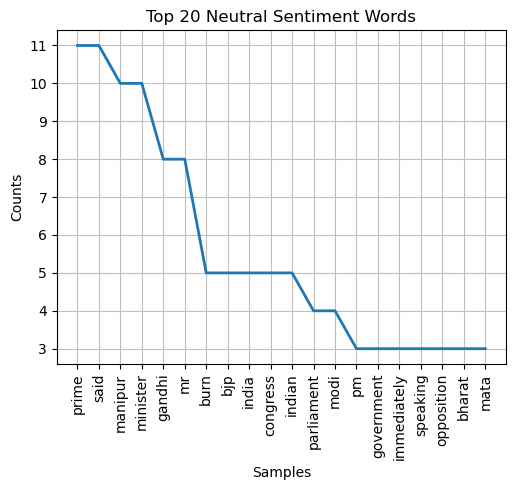

In [83]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
word_freq_positive.plot(20, title="Top 20 Positive Sentiment Words")

plt.figure(figsize=(15, 5))
plt.subplot(132)
word_freq_negative.plot(20, title="Top 20 Negative Sentiment Words")

plt.figure(figsize=(15, 5))
plt.subplot(133)
word_freq_neutral.plot(20, title="Top 20 Neutral Sentiment Words")

plt.tight_layout()
plt.show()

In [84]:
df_positive = pd.DataFrame(word_freq_positive.most_common(20), columns=['Word', 'Frequency'])
df_negative = pd.DataFrame(word_freq_negative.most_common(20), columns=['Word', 'Frequency'])
df_neutral = pd.DataFrame(word_freq_neutral.most_common(20), columns=['Word', 'Frequency'])

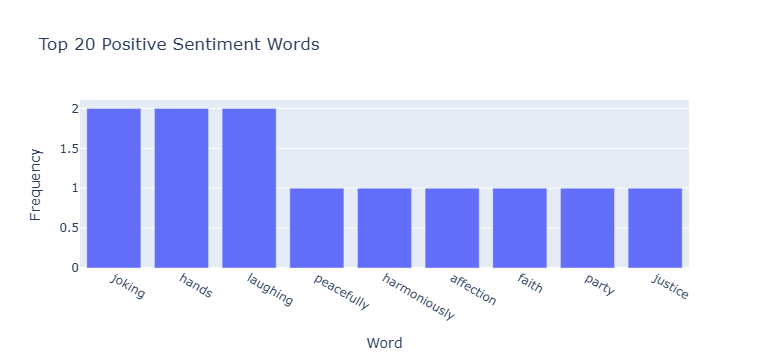

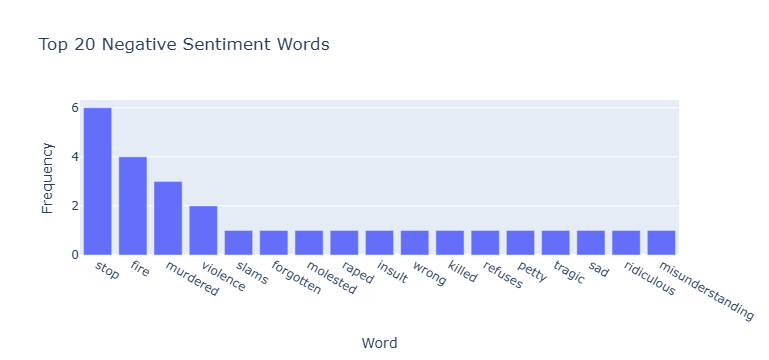

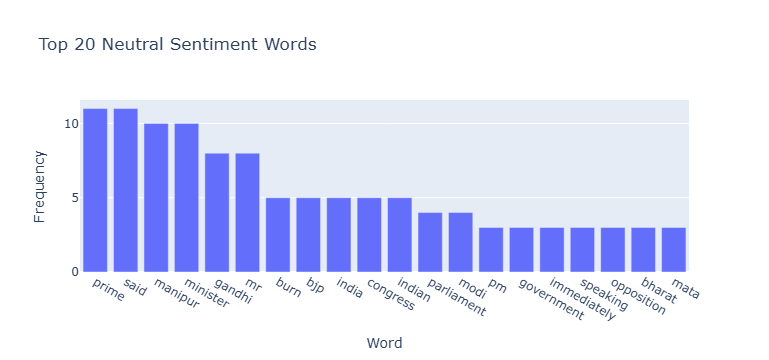

In [85]:
import plotly.express as px
import plotly.graph_objects as go

fig_positive = px.bar(df_positive, x='Word', y='Frequency', title="Top 20 Positive Sentiment Words")
fig_negative = px.bar(df_negative, x='Word', y='Frequency', title="Top 20 Negative Sentiment Words")
fig_neutral = px.bar(df_neutral, x='Word', y='Frequency', title="Top 20 Neutral Sentiment Words")

fig_positive.show()
fig_negative.show()
fig_neutral.show()

In [86]:
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_positive)
wordcloud_negative = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_negative)
wordcloud_neutral = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq_neutral)

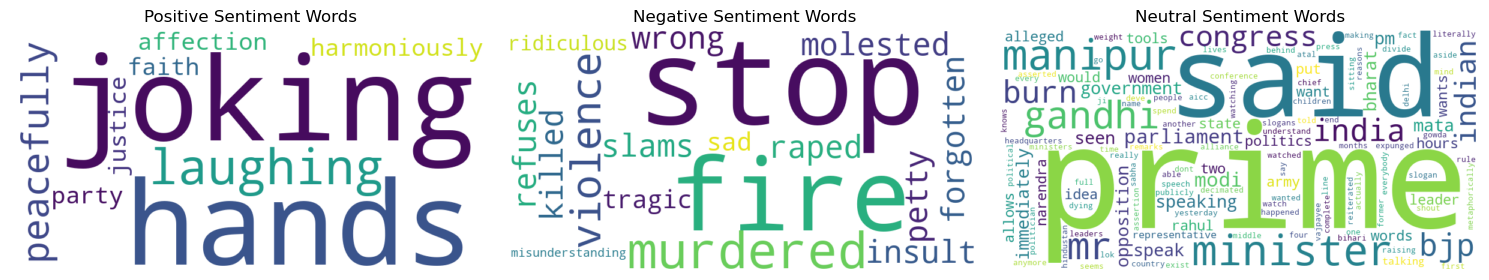

In [87]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment Words")

plt.subplot(132)
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment Words")

plt.subplot(133)
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment Words")

plt.tight_layout()
plt.show()

In [88]:
word_freq = nltk.FreqDist(words_lemmatized)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

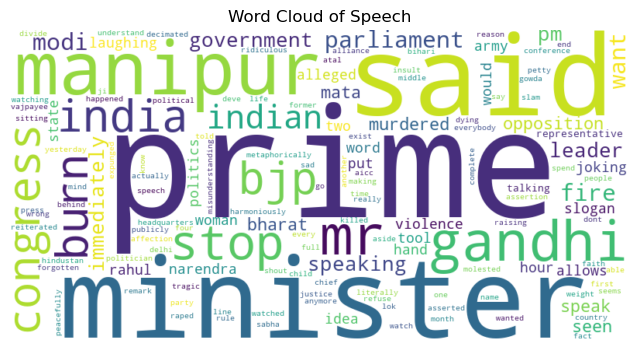

In [89]:
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Speech")
plt.show()

In [90]:
total_words = len(words_filtered)
positive_percentage = (len(positive_words) / total_words) * 100
negative_percentage = (len(negative_words) / total_words) * 100
neutral_percentage = (len(neutral_words) / total_words) * 100

print("Positive Sentiment Percentage:", positive_percentage)
print("Negative Sentiment Percentage:", negative_percentage)
print("Neutral Sentiment Percentage:", neutral_percentage)

Positive Sentiment Percentage: 4.270462633451958
Negative Sentiment Percentage: 9.9644128113879
Neutral Sentiment Percentage: 85.76512455516014


In [91]:
data = {'Sentiment': ['Positive', 'Negative', 'Neutral'],
        'Percentage': [positive_percentage, negative_percentage, neutral_percentage]}

In [92]:
df_percentages = pd.DataFrame(data)

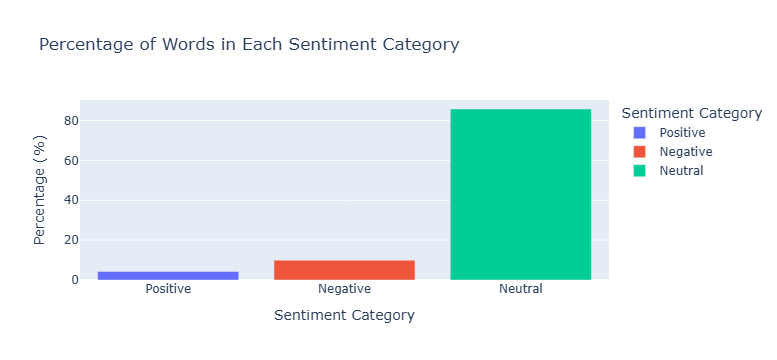

In [93]:
fig = px.bar(df_percentages, x='Sentiment', y='Percentage', color='Sentiment',
             labels={'Sentiment': 'Sentiment Category', 'Percentage': 'Percentage (%)'},
             title='Percentage of Words in Each Sentiment Category')
fig.show()

### V2

VADER is sentence-level, not word-level.

Scoring each word independently gives misleading sentiment.

👉 Correct approach:

    Either sentiment per sentence
    
    Or sentiment per paragraph
    
    Then aggregate

In [94]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import plotly.express as px

#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('vader_lexicon')


In [95]:
file_path = "Rahul Gandhi Speech.txt"

with open(file_path, "r", encoding="utf-8") as f:
    speech_text = f.read()


In [96]:
sia = SentimentIntensityAnalyzer()

sentences = sent_tokenize(speech_text)

sentiment_data = []

for sent in sentences:
    score = sia.polarity_scores(sent)
    sentiment_data.append({
        "sentence": sent,
        "compound": score["compound"]
    })

df_sentiment = pd.DataFrame(sentiment_data)


In [97]:
df_sentiment

,sentence,compound
0,"""Joking In Parliament When Manipur Is On Fire""...",-0.7650
1,"""I watched the Prime Minister yesterday, speak...",0.6249
2,The Prime Minister would say one line and the ...,0.0000
3,The Prime Minister seems to have forgotten tha...,-0.8750
4,"This is not about Rahul Gandhi, it is not abou...",0.0000
5,"A state has been decimated, it does not exist ...",0.0000
6,"""That is why I said the idea of India has been...",-0.6597
7,"I was not speaking metaphorically, I was speak...",0.0000
8,"""That is why in my speech (in Lok Sabha) I sai...",-0.6597
9,"For the first time, the words Bharat Mata have...",0.0000


In [98]:
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_sentiment["sentiment"] = df_sentiment["compound"].apply(label_sentiment)


In [99]:
df_sentiment["sentiment"] 

0     Negative
1     Positive
2      Neutral
3     Negative
4      Neutral
5      Neutral
6     Negative
7      Neutral
8     Negative
9      Neutral
10    Negative
11    Negative
12    Positive
13    Negative
14    Positive
15     Neutral
16    Negative
17    Positive
18    Negative
19    Negative
20     Neutral
21     Neutral
22    Negative
23    Negative
Name: sentiment, dtype: object

In [100]:

sentiment_counts = df_sentiment["sentiment"].value_counts(normalize=True) * 100

sentiment_df = sentiment_counts.reset_index()
sentiment_df.columns = ["sentiment", "proportion"]


In [101]:
sentiment_df

,sentiment,proportion
0,Negative,50.000000
1,Neutral,33.333333
2,Positive,16.666667


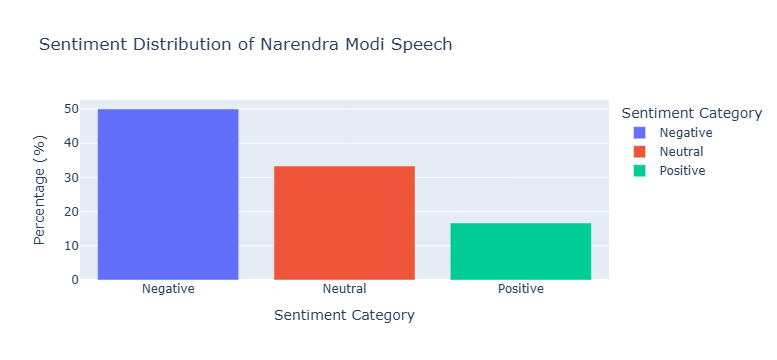

In [102]:
import plotly.express as px

fig = px.bar(
    sentiment_df,
    x="sentiment",
    y="proportion",
    color="sentiment",
    labels={
        "sentiment": "Sentiment Category",
        "proportion": "Percentage (%)"
    },
    title="Sentiment Distribution of Narendra Modi Speech"
)

fig.show()


In [103]:
text_cleaned = re.sub(r"[^\w\s]", "", speech_text.lower())

words = word_tokenize(text_cleaned)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

words_cleaned = [
    lemmatizer.lemmatize(word)
    for word in words
    if word not in stop_words and len(word) > 2
]


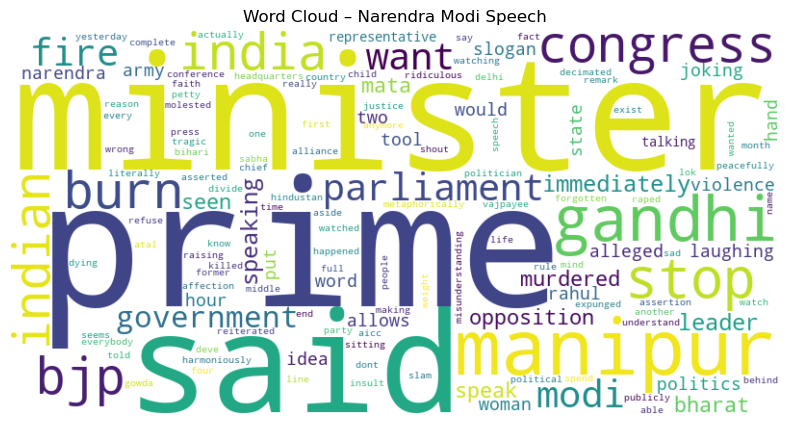

In [104]:
word_freq = nltk.FreqDist(words_cleaned)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Narendra Modi Speech")
plt.show()


“I used VADER for sentence-level sentiment analysis of political speeches, aggregated sentiment distributions, and visualized key themes using frequency-based word clouds.”

https://chatgpt.com/share/6988a4b9-2540-8003-aeaf-2ea885f8ab7f